# Predict Diabetes with Machine Learning

### Capstone Project

**Submitted By:** Chirashree Mallick

**Domain:** Machine Learning Mentorship Program

**Organization:** 1Stop.ai

**Dataset Used:** Pima Indians Diabetes Dataset

**Problem Type:** Binary Classification

**Machine Learning Techniques / Algorithms Used:**
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree Classifier
- Feature Scaling (StandardScaler)
- Classification Evaluation Metrics

**Objective:** To predict whether a patient is diabetic or non-diabetic using medical diagnostic measurements and machine learning algorithms.

# Problem Statement

Diabetes is a chronic medical condition that affects millions of people worldwide.

The objective of this project is to build machine learning classification models capable of predicting whether a patient is diabetic based on medical measurements such as glucose level, blood pressure, BMI, insulin level, age, and other health indicators.

The project involves:
- Data Collection
- Data Cleaning
- Exploratory Data Analysis
- Feature Scaling
- Model Building
- Model Evaluation
- Model Comparison
- Best Model Selection

# Import Required Libraries

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Load Dataset

In [19]:
df = pd.read_csv("diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Initial Data Exploration

In [20]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

### Outcome Variable Description

The target variable in the dataset is **Outcome**.

- 0 → Non-Diabetic Patient
- 1 → Diabetic Patient

The following visualization shows the distribution of diabetic and non-diabetic patients in the dataset.

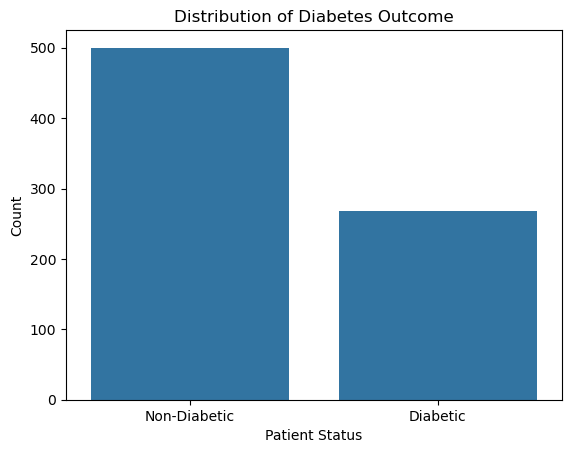

In [23]:
sns.countplot(x='Outcome', data=df)

plt.xticks(
    [0,1],
    ['Non-Diabetic','Diabetic']
)

plt.xlabel("Patient Status")
plt.ylabel("Count")
plt.title("Distribution of Diabetes Outcome")

plt.show()

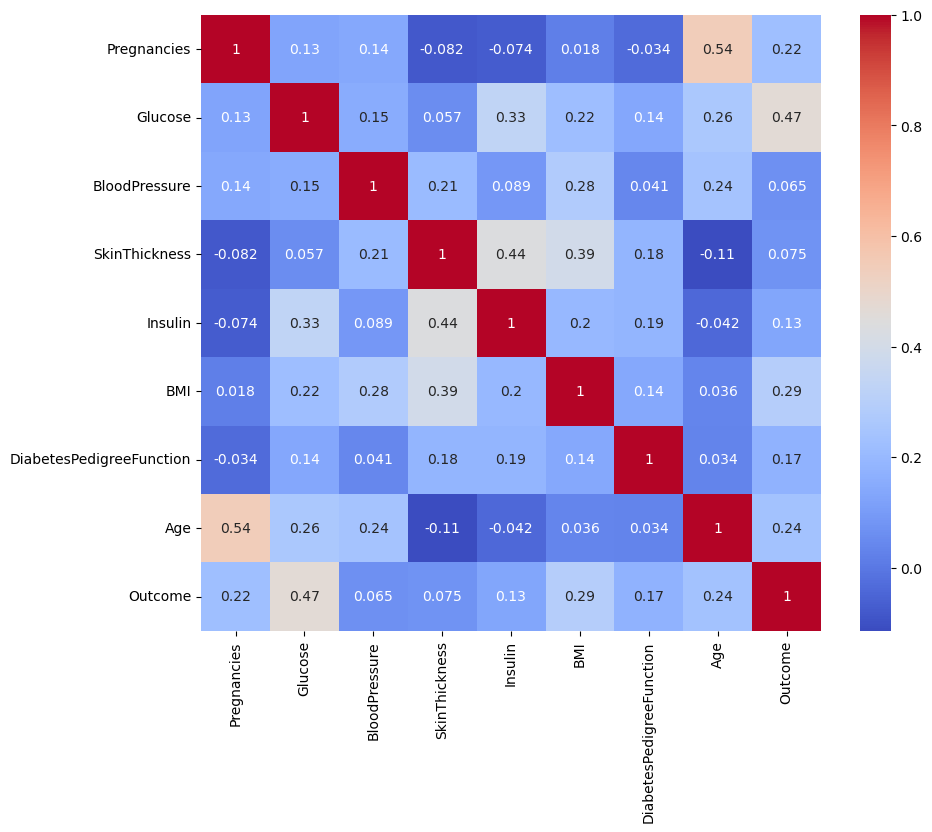

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Feature Selection

In [25]:
X = df.drop(
    'Outcome',
    axis=1
)

y = df['Outcome']

print(X.shape)
print(y.shape)

(768, 8)
(768,)


# Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(576, 8)
(192, 8)


# Feature Scaling

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[ 2.80346794  0.25977903 -3.78077929  0.61677038 -0.69205168  1.03974028
   0.29608546  0.96352088]
 [ 0.07832678  0.25977903  0.89724451 -0.03210586  1.63307692  0.40945373
  -0.70087555 -0.86295593]
 [-0.22446668 -1.85825286  0.67966201  0.48699513 -0.69205168  0.31753694
  -0.66548048  1.13747105]
 [-0.52726014 -1.2353023   0.13570575 -0.35654397 -0.03757104 -0.24709476
   0.2311945  -0.68900576]
 [-1.13284707 -0.58120422  0.29889263  0.16255702 -0.69205168 -4.19951667
   0.30493422 -1.03690611]]


# Result Summarizer Function

In [28]:
def result_summarizer(y_true, y_pred):

    print("Accuracy:",
          accuracy_score(y_true,y_pred))

    print("Precision:",
          precision_score(y_true,y_pred))

    print("Recall:",
          recall_score(y_true,y_pred))

    print("F1 Score:",
          f1_score(y_true,y_pred))

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

# Logistic Regression Model

Accuracy: 0.7291666666666666
Precision: 0.6164383561643836
Recall: 0.6521739130434783
F1 Score: 0.6338028169014085

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.77      0.79       123
           1       0.62      0.65      0.63        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192



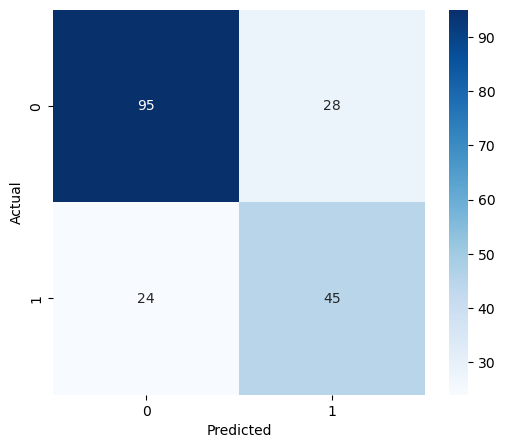

In [29]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

result_summarizer(
    y_test,
    y_pred_lr
)

# K-Nearest Neighbors Model

Accuracy: 0.6822916666666666
Precision: 0.5606060606060606
Recall: 0.5362318840579711
F1 Score: 0.5481481481481482

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       123
           1       0.56      0.54      0.55        69

    accuracy                           0.68       192
   macro avg       0.65      0.65      0.65       192
weighted avg       0.68      0.68      0.68       192



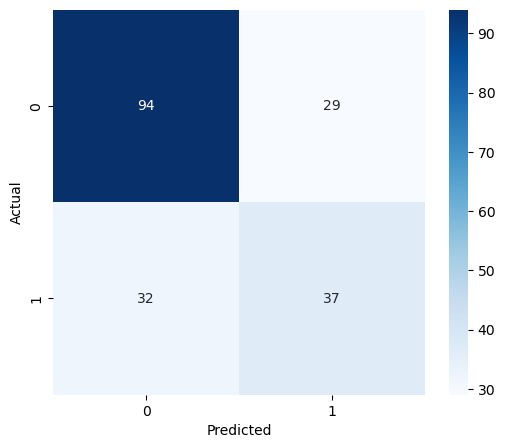

In [30]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test
)

result_summarizer(
    y_test,
    y_pred_knn
)

# Decision Tree Model

Accuracy: 0.7239583333333334
Precision: 0.6212121212121212
Recall: 0.5942028985507246
F1 Score: 0.6074074074074074

Classification Report

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       123
           1       0.62      0.59      0.61        69

    accuracy                           0.72       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.72      0.72      0.72       192



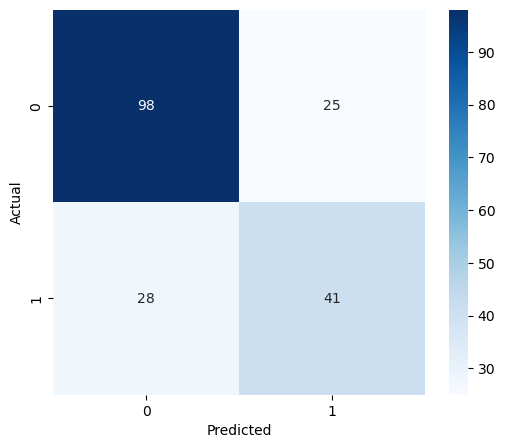

In [31]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(
    X_test
)

result_summarizer(
    y_test,
    y_pred_dt
)

# Model Comparison

In [32]:
comparison = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],

    'Accuracy':[

        accuracy_score(
            y_test,
            y_pred_lr
        ),

        accuracy_score(
            y_test,
            y_pred_knn
        ),

        accuracy_score(
            y_test,
            y_pred_dt
        )
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.729167
1,KNN,0.682292
2,Decision Tree,0.723958


# Best Performing Model

In [33]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy               0.729167
Name: 0, dtype: object


# Conclusion

In this project, machine learning techniques were applied to predict diabetes using medical diagnostic measurements.

Data preprocessing, exploratory data analysis, feature scaling, model training, and model evaluation were successfully performed.

Three classification algorithms namely Logistic Regression, K-Nearest Neighbors (KNN), and Decision Tree Classifier were implemented and evaluated using confusion matrices, classification reports, accuracy, precision, recall, and F1-score metrics.

Among the evaluated models, **Logistic Regression** achieved the highest classification accuracy and demonstrated strong capability in distinguishing diabetic and non-diabetic patients based on health indicators.

The results indicate that machine learning algorithms can effectively support early diabetes prediction and can assist healthcare professionals in identifying high-risk patients for timely diagnosis and treatment.

This project demonstrates the practical application of machine learning in healthcare analytics and predictive medical diagnosis.